# Star Field Motion by Contrast Maximization

Estimates one global image velocity for a rotating star field by contrast maximization and compares it with the ground truth. Data: Chin et al., "Star Tracking using an Event Camera" (CVPRW 2019). These are stars rendered by Stellarium on a screen and filmed with a DAVIS 240C, not the real sky.

## 1. Setup and data download

`scripts/download_data.py stars` fetches the dataset archive (~430 MB, from its Internet Archive copy because the project page is gone) and unpacks one sequence into `data/stars/`.

In [1]:
import os, sys
if "google.colab" in sys.modules:
    REPO = "/content/event-perception"
    if not os.path.exists(REPO):
        !git clone https://github.com/allusson/event-perception.git {REPO}
    %cd {REPO}
    !pip install -q -e .
    sys.path.insert(0, REPO)
else:
    # local: assumes `pip install -e .` was run from the repo root
    os.chdir(os.path.dirname(os.path.abspath("")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from evcam.io import load_star_sequence, rotation_flow, crop_time, STAR_SHAPE
from evcam.cmax import iwe, contrast, cmax_patch

SEQ = 3
!{sys.executable} scripts/download_data.py stars --star-sequences {SEQ}

Stars [3] -> data/stars
done: ['CameraMatrix', 'ReadMe', 'Sequence3.csv', 'Sequence3_attitudes', 'adelaide_event_star_tracking_dataset.zip']


## 2. Load a sequence and take a window

Events are (x, y, t, p) on the 240×180 sensor; the ground truth is a constant angular velocity $\boldsymbol{\omega}$ of 4°/s and a camera matrix $\mathsf{M}$ that maps a pixel to its star direction. The stars move only about 11 px/s, so a 100-200 ms window shows dots; a 2 s window gives clear streaks.

In [3]:
T_START_S, WINDOW_S = 5.0, 2.0
H, W = STAR_SHAPE

all_events, gt = load_star_sequence(SEQ)
ev = crop_time(all_events, int(T_START_S * 1e6), int(WINDOW_S * 1e6))
x, y, tn = ev["x"].astype(float), ev["y"].astype(float), ev["t"] / (WINDOW_S * 1e6)
print(f"sequence {SEQ}: {len(all_events):,} events over {all_events['t'][-1] / 1e6:.1f} s, "
      f"rotation rate {np.degrees(np.linalg.norm(gt['omega'])):.2f} deg/s")
print(f"window: {len(ev):,} events in {WINDOW_S:.1f} s")

sequence 3: 1,058,835 events over 45.0 s, rotation rate 4.00 deg/s
window: 52,892 events in 2.0 s


## 3. One global velocity by contrast maximization

`cmax_patch` (`evcam/cmax.py`) is run with the whole frame as its single patch: every event is warped with the same velocity $\mathbf{v}$ and the velocity with the highest variance of the image of warped events $H$ is kept.

$$\mathbf{x}'_k = \mathbf{x}_k - \mathbf{v}\,(t_k - t_\text{ref}), \qquad \hat{\mathbf{v}} = \arg\max_{\mathbf{v}} \operatorname{Var}\big(H(\mathbf{x}; \mathbf{v})\big)$$

CMax velocity: (12.0, 3.5) px/s


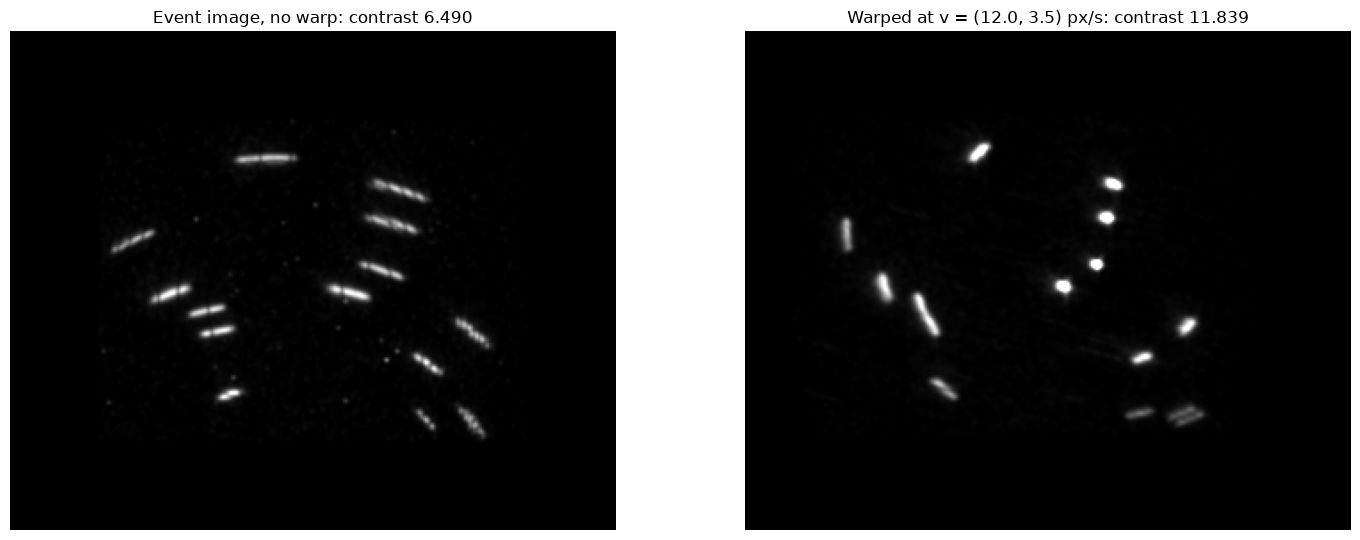

In [4]:
PAD, RNG = 50, 48          # canvas padding (px) and search half-range (px per window)
canvas, origin = (H + 2 * PAD, W + 2 * PAD), (-PAD, -PAD)
warp = lambda d: iwe(x, y, tn, d, canvas, origin)      # d in px per window

d_best, _ = cmax_patch(x, y, tn, (0, 0, W, H), pad=PAD, rng=RNG, coarse=4)
v_cmax = d_best / WINDOW_S                              # px/s
img0, img1 = warp((0, 0)), warp(d_best)
print(f"CMax velocity: ({v_cmax[0]:.1f}, {v_cmax[1]:.1f}) px/s")

vmax = np.percentile(img1, 99.8)
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
ax[0].imshow(img0, cmap="gray", vmax=vmax); ax[0].set_title(f"Event image, no warp: contrast {contrast(img0):.3f}")
ax[1].imshow(img1, cmap="gray", vmax=vmax)
ax[1].set_title(f"Warped at v = ({v_cmax[0]:.1f}, {v_cmax[1]:.1f}) px/s: contrast {contrast(img1):.3f}")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 4. Contrast landscape

Variance of the image of warped events on a grid of velocities, in steps of 2 px per window (1 px/s).

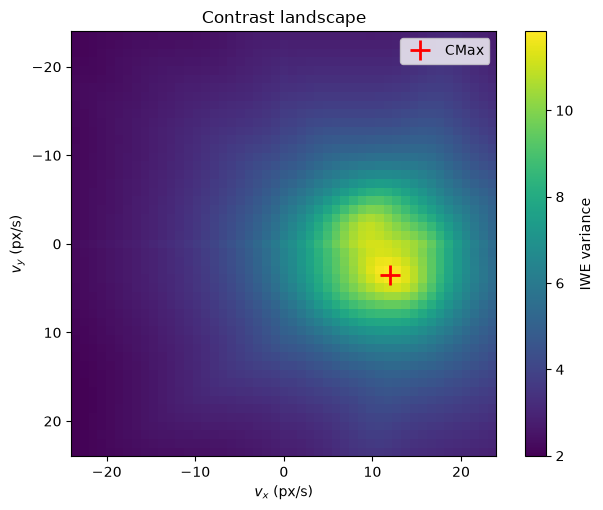

In [5]:
grid = np.arange(-RNG, RNG + 1, 2.0)                    # px per window
S = np.array([[contrast(warp((dx, dy))) for dx in grid] for dy in grid])
gv = grid / WINDOW_S                                    # px/s

plt.figure(figsize=(6.5, 5.2))
plt.imshow(S, extent=[gv[0], gv[-1], gv[-1], gv[0]], cmap="viridis")
plt.colorbar(label="IWE variance")
plt.plot(*v_cmax, "r+", ms=14, mew=2, label="CMax")
plt.xlabel("$v_x$ (px/s)"); plt.ylabel("$v_y$ (px/s)"); plt.title("Contrast landscape"); plt.legend()
plt.tight_layout(); plt.show()

## 5. Comparison with ground truth

A star with direction $\mathbf{d} = \mathsf{M}\,(x, y, 1)^\top$ moves with $\dot{\mathbf{d}} = \boldsymbol{\omega} \times \mathbf{d}$, which `rotation_flow` (`evcam/io.py`) projects back to the image. The rotation axis is only about 11° from the optical axis, so the true motion is a rotation in the image plane about a point below the frame, and one translation cannot describe it. The CMax estimate is compared with the ground-truth velocity averaged over the events, and the translation warp with a warp of every event by its own ground-truth velocity.

$$\dot{\mathbf{x}} = \mathbf{q}_{1:2} - \mathbf{x}\, q_3, \qquad \mathbf{q} = \mathsf{M}^{-1}\big(\boldsymbol{\omega} \times \mathsf{M}\,(x, y, 1)^\top\big)$$

rotation centre: (97, 240) px (frame is 240 x 180)
GT velocity over the events: mean (10.8, 1.6) px/s, speed from 4.4 to 20.3 px/s
CMax velocity:               (12.0, 3.5) px/s, 2.3 px/s from the GT mean
contrast: no warp 6.490   CMax translation 11.839   GT rotation 18.053


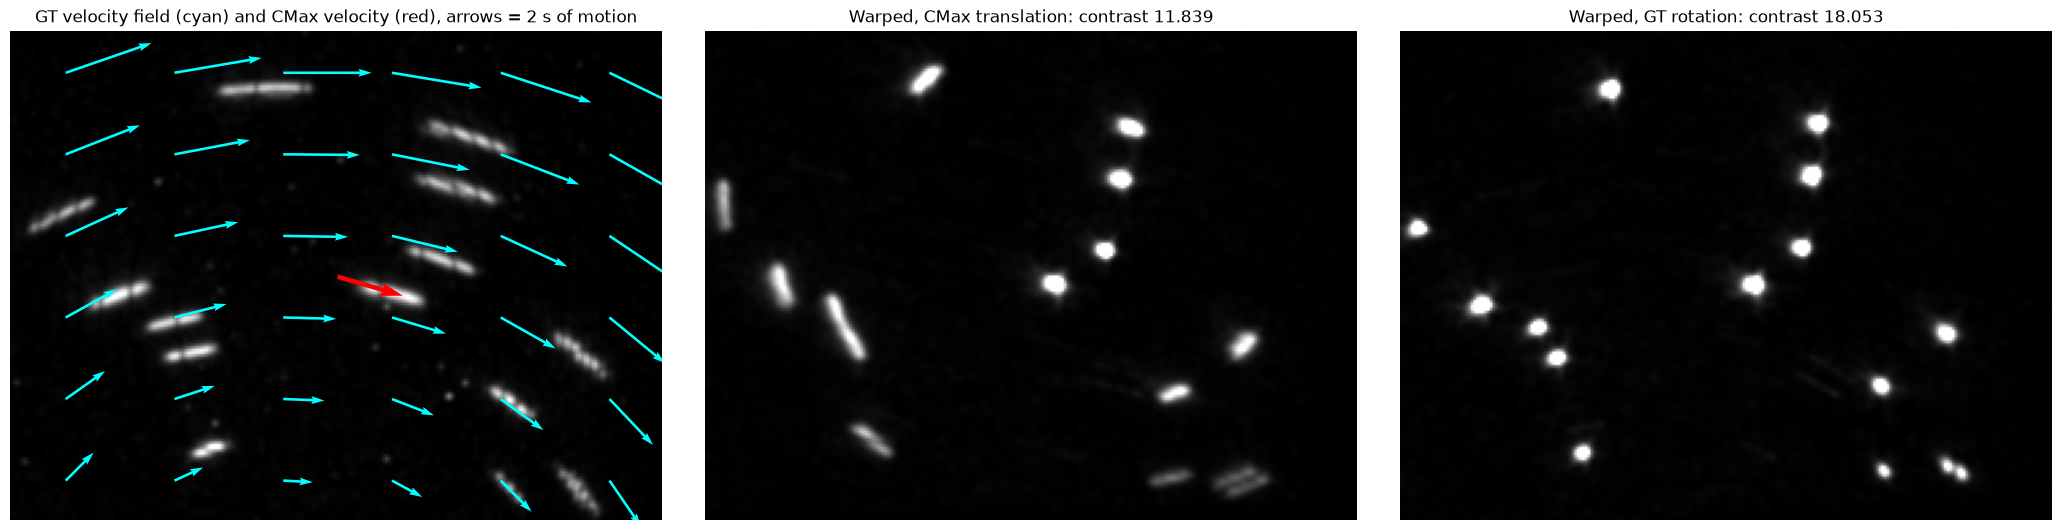

In [6]:
M, omega = gt["camera_matrix"], gt["omega"]
v_gt_ev = rotation_flow(M, omega, x, y)                 # (N, 2) px/s, one per event
v_gt_mean = v_gt_ev.mean(axis=0)
c = np.linalg.solve(M, omega); c = c[:2] / c[2]         # pixel the image rotates about
print(f"rotation centre: ({c[0]:.0f}, {c[1]:.0f}) px (frame is {W} x {H})")
print(f"GT velocity over the events: mean ({v_gt_mean[0]:.1f}, {v_gt_mean[1]:.1f}) px/s, "
      f"speed from {np.linalg.norm(v_gt_ev, axis=1).min():.1f} to {np.linalg.norm(v_gt_ev, axis=1).max():.1f} px/s")
print(f"CMax velocity:               ({v_cmax[0]:.1f}, {v_cmax[1]:.1f}) px/s, "
      f"{np.linalg.norm(v_cmax - v_gt_mean):.1f} px/s from the GT mean")

# warp every event with its own ground-truth velocity (straight-line approximation of the arc)
d_gt = v_gt_ev * WINDOW_S
img_gt = warp((d_gt[:, 0], d_gt[:, 1]))
print(f"contrast: no warp {contrast(img0):.3f}   CMax translation {contrast(img1):.3f}   GT rotation {contrast(img_gt):.3f}")

gx, gy = np.meshgrid(np.arange(20, W, 40.0), np.arange(15, H, 30.0))
g = rotation_flow(M, omega, gx.ravel(), gy.ravel())
fig, ax = plt.subplots(1, 3, figsize=(21, 5.2))
ax[0].imshow(img0[PAD:-PAD, PAD:-PAD], cmap="gray", vmax=vmax)
ax[0].quiver(gx.ravel(), gy.ravel(), g[:, 0], g[:, 1], color="cyan", angles="xy", scale_units="xy", scale=0.5, width=0.004)
ax[0].quiver(W / 2, H / 2, *v_cmax, color="red", angles="xy", scale_units="xy", scale=0.5, width=0.007)
ax[0].set_title("GT velocity field (cyan) and CMax velocity (red), arrows = 2 s of motion")
ax[1].imshow(img1[PAD:-PAD, PAD:-PAD], cmap="gray", vmax=vmax); ax[1].set_title(f"Warped, CMax translation: contrast {contrast(img1):.3f}")
ax[2].imshow(img_gt[PAD:-PAD, PAD:-PAD], cmap="gray", vmax=vmax); ax[2].set_title(f"Warped, GT rotation: contrast {contrast(img_gt):.3f}")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()